In [17]:
import pandas as pd
import numpy as np

customer_360 = pd.read_csv(
    "../data/processed/customer_360.csv"
)

print(customer_360.shape)
customer_360.head()

(96096, 47)


,customer_unique_id,total_orders,total_items,total_spent,total_freight,unique_products,unique_sellers,avg_order_value,last_purchase_date,recency_days,...,R_score,F_score,M_score,RFM_score,customer_segment,spend_score,frequency_score,customer_value_score,cluster,kmeans_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1.0,141.90,12.00,1.0,1.0,141.90,2018-05-10 10:56:27,160,...,4,1,4,9,Potential,0.010385,0.0,0.007269,0,One-Time Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1.0,27.19,8.29,1.0,1.0,27.19,2018-05-07 11:11:27,163,...,4,1,1,6,Low Value,0.001990,0.0,0.001393,0,One-Time Customers
2,0000f46a3911fa3c0805444483337064,1,1.0,86.22,17.22,1.0,1.0,86.22,2017-03-10 21:05:03,585,...,1,1,2,4,Low Value,0.006310,0.0,0.004417,0,One-Time Customers
3,0000f6ccb0745a6a4b88665a16c9f078,1,1.0,43.62,17.63,1.0,1.0,43.62,2017-10-12 20:29:41,369,...,2,1,1,4,Low Value,0.003192,0.0,0.002235,0,One-Time Customers
4,0004aac84e0df4da2b147fca70cf8255,1,1.0,196.89,16.89,1.0,1.0,196.89,2017-11-14 19:45:42,336,...,2,1,4,7,Potential,0.014409,0.0,0.010087,0,One-Time Customers


In [18]:
print(customer_360[
    [
        "customer_unique_id",
        "total_orders",
        "total_spent",
        "avg_order_value",
        "customer_lifetime_days",
        "active_months"
    ]
].head())

                 customer_unique_id  total_orders  total_spent  \
0  0000366f3b9a7992bf8c76cfdf3221e2             1       141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f             1        27.19   
2  0000f46a3911fa3c0805444483337064             1        86.22   
3  0000f6ccb0745a6a4b88665a16c9f078             1        43.62   
4  0004aac84e0df4da2b147fca70cf8255             1       196.89   

   avg_order_value  customer_lifetime_days  active_months  
0           141.90                       0            0.0  
1            27.19                       0            0.0  
2            86.22                       0            0.0  
3            43.62                       0            0.0  
4           196.89                       0            0.0  


In [19]:
# CLV components

customer_360["purchase_frequency"] = (
    customer_360["total_orders"] /
    customer_360["active_months"].replace(0,1)
)

customer_360["purchase_frequency"] =(
    customer_360["purchase_frequency"].replace(
        [float("inf"), -float("inf")],
        0
    )
)

print(
    customer_360[
        [
            "customer_unique_id",
            "total_orders",
            "total_spent",
            "active_months",
            "purchase_frequency"
        ]
    ].head(10)
)

                 customer_unique_id  total_orders  total_spent  active_months  \
0  0000366f3b9a7992bf8c76cfdf3221e2             1       141.90            0.0   
1  0000b849f77a49e4a4ce2b2a4ca5be3f             1        27.19            0.0   
2  0000f46a3911fa3c0805444483337064             1        86.22            0.0   
3  0000f6ccb0745a6a4b88665a16c9f078             1        43.62            0.0   
4  0004aac84e0df4da2b147fca70cf8255             1       196.89            0.0   
5  0004bd2a26a76fe21f786e4fbd80607f             1       166.98            0.0   
6  00050ab1314c0e55a6ca13cf7181fecf             1        35.38            0.0   
7  00053a61a98854899e70ed204dd4bafe             1       419.18            0.0   
8  0005e1862207bf6ccc02e4228effd9a0             1       150.12            0.0   
9  0005ef4cd20d2893f0d9fbd94d3c0d97             1       129.76            0.0   

   purchase_frequency  
0                 1.0  
1                 1.0  
2                 1.0  
3           

In [4]:
# Average Monthly Revenue

customer_360["monthly_value"] = (
    customer_360["total_orders"] /
    customer_360["active_months"].replace(0,1)
)

customer_360["monthly_value"] = (
    customer_360["monthly_value"]
    .replace([float("inf"), -float("inf")],0 )
)

print(
    customer_360[
        [
            "customer_unique_id",
            "total_spent",
            "active_months",
            "monthly_value"
        ]
    ].head(10)
)



                 customer_unique_id  total_spent  active_months  monthly_value
0  0000366f3b9a7992bf8c76cfdf3221e2       141.90            0.0            1.0
1  0000b849f77a49e4a4ce2b2a4ca5be3f        27.19            0.0            1.0
2  0000f46a3911fa3c0805444483337064        86.22            0.0            1.0
3  0000f6ccb0745a6a4b88665a16c9f078        43.62            0.0            1.0
4  0004aac84e0df4da2b147fca70cf8255       196.89            0.0            1.0
5  0004bd2a26a76fe21f786e4fbd80607f       166.98            0.0            1.0
6  00050ab1314c0e55a6ca13cf7181fecf        35.38            0.0            1.0
7  00053a61a98854899e70ed204dd4bafe       419.18            0.0            1.0
8  0005e1862207bf6ccc02e4228effd9a0       150.12            0.0            1.0
9  0005ef4cd20d2893f0d9fbd94d3c0d97       129.76            0.0            1.0


In [20]:
# Calculate Average Order Value

customer_360["avg_order_value_clv"] = (
    customer_360["total_spent"] /
    customer_360["total_orders"].replace(0,1)
)

print(
    customer_360[
        [
            "customer_unique_id",
            "total_orders",
            "total_spent",
            "avg_order_value_clv"
        ]
    ].head(10)
)

                 customer_unique_id  total_orders  total_spent  \
0  0000366f3b9a7992bf8c76cfdf3221e2             1       141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f             1        27.19   
2  0000f46a3911fa3c0805444483337064             1        86.22   
3  0000f6ccb0745a6a4b88665a16c9f078             1        43.62   
4  0004aac84e0df4da2b147fca70cf8255             1       196.89   
5  0004bd2a26a76fe21f786e4fbd80607f             1       166.98   
6  00050ab1314c0e55a6ca13cf7181fecf             1        35.38   
7  00053a61a98854899e70ed204dd4bafe             1       419.18   
8  0005e1862207bf6ccc02e4228effd9a0             1       150.12   
9  0005ef4cd20d2893f0d9fbd94d3c0d97             1       129.76   

   avg_order_value_clv  
0               141.90  
1                27.19  
2                86.22  
3                43.62  
4               196.89  
5               166.98  
6                35.38  
7               419.18  
8               150.12  
9               129.76 

In [24]:
# Calculate Customer Lifetime Value

customer_360["lifetime_months_clv"] = (
    customer_360["customer_lifetime_days"] / 30
)

customer_360["lifetime_months_clv"] = (
    customer_360["lifetime_months_clv"].replace(0,1)
)

print(
    customer_360[
        [
            "customer_unique_id",
            "customer_lifetime_days",
            "lifetime_months_clv"
        ]
    ].head(10)
)

                 customer_unique_id  customer_lifetime_days  \
0  0000366f3b9a7992bf8c76cfdf3221e2                       0   
1  0000b849f77a49e4a4ce2b2a4ca5be3f                       0   
2  0000f46a3911fa3c0805444483337064                       0   
3  0000f6ccb0745a6a4b88665a16c9f078                       0   
4  0004aac84e0df4da2b147fca70cf8255                       0   
5  0004bd2a26a76fe21f786e4fbd80607f                       0   
6  00050ab1314c0e55a6ca13cf7181fecf                       0   
7  00053a61a98854899e70ed204dd4bafe                       0   
8  0005e1862207bf6ccc02e4228effd9a0                       0   
9  0005ef4cd20d2893f0d9fbd94d3c0d97                       0   

   lifetime_months_clv  
0                  1.0  
1                  1.0  
2                  1.0  
3                  1.0  
4                  1.0  
5                  1.0  
6                  1.0  
7                  1.0  
8                  1.0  
9                  1.0  


In [27]:
customer_360["clv"] = (
    customer_360["avg_order_value_clv"]
    * customer_360["purchase_frequency"]
    * customer_360["lifetime_months_clv"]
)

print(
    customer_360[
        [
            "customer_unique_id",
            "avg_order_value_clv",
            "purchase_frequency",
            "lifetime_months_clv",
            "clv"
        ]
    ].head(10)
)

                 customer_unique_id  avg_order_value_clv  purchase_frequency  \
0  0000366f3b9a7992bf8c76cfdf3221e2               141.90                 1.0   
1  0000b849f77a49e4a4ce2b2a4ca5be3f                27.19                 1.0   
2  0000f46a3911fa3c0805444483337064                86.22                 1.0   
3  0000f6ccb0745a6a4b88665a16c9f078                43.62                 1.0   
4  0004aac84e0df4da2b147fca70cf8255               196.89                 1.0   
5  0004bd2a26a76fe21f786e4fbd80607f               166.98                 1.0   
6  00050ab1314c0e55a6ca13cf7181fecf                35.38                 1.0   
7  00053a61a98854899e70ed204dd4bafe               419.18                 1.0   
8  0005e1862207bf6ccc02e4228effd9a0               150.12                 1.0   
9  0005ef4cd20d2893f0d9fbd94d3c0d97               129.76                 1.0   

   lifetime_months_clv     clv  
0                  1.0  141.90  
1                  1.0   27.19  
2                  1

In [28]:
print(customer_360["clv"].describe())

count    96096.000000
mean       164.872141
std        227.938658
min          0.000000
25%         62.390000
50%        107.270000
75%        182.237500
max      13664.080000
Name: clv, dtype: float64


In [29]:
customer_360["clv_segment"] = pd.qcut(
    customer_360["clv"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "Very High Value"
    ],
    duplicates="drop"
)

print(customer_360["clv_segment"].value_counts())

clv_segment
Low Value          24033
Very High Value    24024
High Value         24021
Medium Value       24018
Name: count, dtype: int64


In [30]:
print(customer_360.columns.tolist())

['customer_unique_id', 'total_orders', 'total_items', 'total_spent', 'total_freight', 'unique_products', 'unique_sellers', 'avg_order_value', 'last_purchase_date', 'recency_days', 'first_purchase_date', 'customer_lifetime_days', 'active_months', 'avg_review_score', 'total_reviews', 'has_review', 'total_payment', 'avg_payment_value', 'total_payment_records', 'max_installments', 'credit_card_payments', 'boleto_payments', 'voucher_payments', 'debit_card_payments', 'avg_delivery_days', 'max_delivery_days', 'avg_delivery_delay', 'late_orders', 'on_time_orders', 'purchase_frequency', 'spend_per_item', 'orders_per_seller', 'products_per_order', 'freight_cost_ratio', 'payment_to_spent_ratio', 'seller_diversity', 'spend_per_order', 'R_score', 'F_score', 'M_score', 'RFM_score', 'customer_segment', 'spend_score', 'frequency_score', 'customer_value_score', 'cluster', 'kmeans_segment', 'avg_order_value_clv', 'lifetime_months_clv', 'clv', 'clv_segment']


In [31]:
customer_360.columns.tolist()

['customer_unique_id',
 'total_orders',
 'total_items',
 'total_spent',
 'total_freight',
 'unique_products',
 'unique_sellers',
 'avg_order_value',
 'last_purchase_date',
 'recency_days',
 'first_purchase_date',
 'customer_lifetime_days',
 'active_months',
 'avg_review_score',
 'total_reviews',
 'has_review',
 'total_payment',
 'avg_payment_value',
 'total_payment_records',
 'max_installments',
 'credit_card_payments',
 'boleto_payments',
 'voucher_payments',
 'debit_card_payments',
 'avg_delivery_days',
 'max_delivery_days',
 'avg_delivery_delay',
 'late_orders',
 'on_time_orders',
 'purchase_frequency',
 'spend_per_item',
 'orders_per_seller',
 'products_per_order',
 'freight_cost_ratio',
 'payment_to_spent_ratio',
 'seller_diversity',
 'spend_per_order',
 'R_score',
 'F_score',
 'M_score',
 'RFM_score',
 'customer_segment',
 'spend_score',
 'frequency_score',
 'customer_value_score',
 'cluster',
 'kmeans_segment',
 'avg_order_value_clv',
 'lifetime_months_clv',
 'clv',
 'clv_segmen

In [32]:
clv_summary = (
    customer_360
    .groupby("clv_segment", observed=True)["clv"]
    .agg(["count", "mean", "median", "min","max"])
)
print(clv_summary)

                 count        mean   median     min       max
clv_segment                                                  
Low Value        24033   42.004048   43.100    0.00     62.39
Medium Value     24018   82.911679   82.245   62.40    107.27
High Value       24021  140.571238  138.620  107.28    182.23
Very High Value  24024  394.024123  277.275  182.26  13664.08


AttributeError: module 'matplotlib.pyplot' has no attribute 'right_layout'

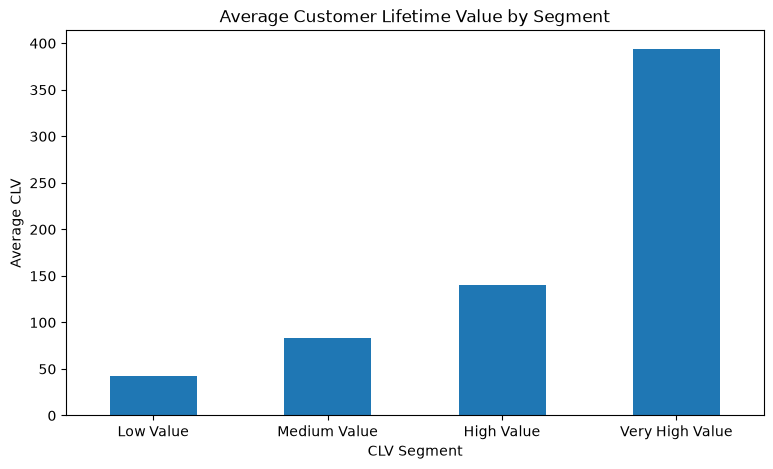

In [33]:
import matplotlib.pyplot as plt
clv_summary["mean"].plot(
    kind = "bar",
    figsize = (9,5)
)
plt.xlabel("CLV Segment")
plt.ylabel("Average CLV")
plt.title("Average Customer Lifetime Value by Segment")
plt.xticks(rotation=0)
plt.right_layout()
plt.show()



In [34]:
# Total CLV contribution by segment
clv_contribution = (
    customer_360
    .groupby("clv_segment", observed= True)["clv"]
    .agg(["count", "sum", "mean"])
)

clv_contribution["percentage_of_total_cl"] =(
    clv_contribution["sum"] /
    customer_360["clv"].sum()
) * 100
print(clv_contribution)

                 count         sum        mean  percentage_of_total_cl
clv_segment                                                           
Low Value        24033  1009483.29   42.004048                6.371571
Medium Value     24018  1991372.70   82.911679               12.568978
High Value       24021  3376661.72  140.571238               21.312528
Very High Value  24024  9466035.53  394.024123               59.746923


In [35]:
customer_360.to_csv(
    "../data/processed/customer_clv.csv",
    index=False
)

print("Customer CLV data saved successfully!")

Customer CLV data saved successfully!


In [36]:
clv_summary.to_csv(
    "../data/processed/clv_summary.csv"
)

print("CLV summary saved successfully!")

CLV summary saved successfully!


In [37]:
clv_contribution.to_csv(
    "../data/processed/clv_contribution.csv"
)

print("CLV contribution saved successfully!")

CLV contribution saved successfully!


In [38]:
top_clv_customers = (
    customer_360[
        [
            "customer_unique_id",
            "total_orders",
            "total_spent",
            "avg_order_value_clv",
            "purchase_frequency",
            "lifetime_months_clv",
            "clv",
            "clv_segment"
        ]
    ]
    .sort_values("clv", ascending=False)
    .head(20)
)

print(top_clv_customers)

                     customer_unique_id  total_orders  total_spent  \
3826   0a0a92112bd4c708ca5fde585afaa872             1     13664.08   
81962  da122df9eeddfedc1dc1f5349a1a690c             2      7571.63   
44447  763c8b1c9c68a0229c42c9fc6f662b93             1      7274.88   
82808  dc4802a71eae9be1dd28f5d788ceb526             1      6929.31   
26205  459bef486812aa25204be022145caa62             1      6922.21   
95806  ff4159b92c40ebe40454e3e6a7c35ed6             1      6726.66   
24121  4007669dec559734d6f53e029e360987             1      6081.54   
35070  5d0a2980b292d049061542014e8960bf             1      4809.44   
89688  eebb5dda148d3893cdaf5b5ca3040ccb             1      4764.34   
27441  48e1ac109decbb87765a3eade6854098             1      4681.78   
75269  c8460e4251689ba205045f3ea17884a1             4      4655.88   
89385  edde2314c6c30e864a128ac95d6b2112             1      4513.32   
60913  a229eba70ec1c2abef51f04987deb7a5             1      4445.50   
89420  edf81e1f3070b

In [39]:
print("Total customers:", len(customer_360))
print("Total CLV:", customer_360["clv"].sum())
print("Average CLV:", customer_360["clv"].mean())
print("Median CLV:", customer_360["clv"].median())

Total customers: 96096
Total CLV: 15843553.24
Average CLV: 164.87214077589078
Median CLV: 107.27


In [40]:
customer_360.to_csv(
    "../data/processed/customer_clv.csv",
    index=False
)

clv_summary.to_csv(
    "../data/processed/clv_summary.csv"
)

clv_contribution.to_csv(
    "../data/processed/clv_contribution.csv"
)

print("Part 08 completed and all CLV files saved successfully!")

Part 08 completed and all CLV files saved successfully!


In [41]:
# Final Part 08 validation

required_columns = [
    "purchase_frequency",
    "avg_order_value_clv",
    "lifetime_months_clv",
    "clv",
    "clv_segment"
]

print("Checking required columns...")

for col in required_columns:
    print(col, ":", col in customer_360.columns)

print("\nMissing CLV values:",
      customer_360["clv"].isna().sum())

print("Infinite CLV values:",
      np.isinf(customer_360["clv"]).sum())

print("Total customers:",
      len(customer_360))

print("\nPart 08 validation completed!")

Checking required columns...
purchase_frequency : True
avg_order_value_clv : True
lifetime_months_clv : True
clv : True
clv_segment : True

Missing CLV values: 0
Infinite CLV values: 0
Total customers: 96096

Part 08 validation completed!


In [42]:
customer_360.to_csv(
    "../data/processed/customer_clv.csv",
    index=False
)

clv_summary.to_csv(
    "../data/processed/clv_summary.csv"
)

clv_contribution.to_csv(
    "../data/processed/clv_contribution.csv"
)

print("Part 08 files saved successfully!")

Part 08 files saved successfully!
